# 07 — Portfolio risk decomposition and factor attribution (extras)

> **About this notebook:** this is an *extras* notebook — an independent application of the project's Fama-French 5-factor infrastructure, not part of the cross-sectional return prediction narrative documented in notebooks 00-06. The README's Executive summary, Methodology, and Discussion sections are about predicting cross-sectional returns; this notebook is about decomposing the *risk and realized return of a fixed portfolio* using the same FF5 data adapter built for the project's baseline experiments. The notebook number jumps from 06 to 07 to signal this scope shift.

**Why this notebook exists:** the project's `src/price_model/data/sources/fama_french.py` and `src/price_model/features/factor_loadings.py` modules were built to support the `ff_factor_pit_v1` comparison baseline and the rolling-beta features in the v3 panel. This notebook demonstrates that those modules can be reused for the orthogonal task of *portfolio attribution*. The factor infrastructure earns its keep across two distinct use cases.

**Two questions answered, both useful regardless of whether you have alpha:**

1. **Risk decomposition (ex-ante)** — what is the portfolio *actually* betting on? Decomposing per-stock factor exposures into portfolio-level loadings reveals accidental concentrations (e.g., "I thought I had diversification but I'm long 1.3 units of market and 0.4 units of value").
2. **Realized attribution (ex-post)** — over a recent window, how much of the realized return came from factor exposures vs. residual stock-picking alpha?

Neither requires a predictive model. The project's PIT-correct cross-sectional return predictor (headline 9-feature L1 regression at IC +0.0695, t = +5.25 on the 21-day 2025+ OOS slice) is a separate workstream; the *factor infrastructure* underneath is reused here for portfolio-risk decomposition irrespective of model performance.


In [1]:
from __future__ import annotations

from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from price_model.data.sources import fama_french, yfinance_source

# ----- Configure portfolio --------------------------------------------------
PORTFOLIO: dict[str, float] = {
    "AAPL":  0.10,
    "AMD":   0.10,
    "MU":    0.10,
    "WMT":   0.10,
    "BRK-B": 0.10,   # yfinance convention; tickers.py normalizes BRK.B → BRK-B
    "MSFT":  0.10,
    "BLK":   0.10,
    "ANET":  0.10,
    "COST":  0.10,
    "JPM":   0.10,
}

# ----- Evaluation window ----------------------------------------------------
# Trailing 252 trading days (~1 year) ending today.
FETCH_START = (date.today() - timedelta(days=400)).isoformat()
REGRESSION_WINDOW = 252      # days used to fit each stock's FF5 betas
ATTRIBUTION_WINDOW = 252     # days over which we attribute realized P&L

assert abs(sum(PORTFOLIO.values()) - 1.0) < 1e-6, "Weights must sum to 1.0"
print(f"Portfolio of {len(PORTFOLIO)} positions:")
for t, w in PORTFOLIO.items():
    print(f"  {t:8s} {w * 100:5.1f}%")

Portfolio of 10 positions:
  AAPL      10.0%
  AMD       10.0%
  MU        10.0%
  WMT       10.0%
  BRK-B     10.0%
  MSFT      10.0%
  BLK       10.0%
  ANET      10.0%
  COST      10.0%
  JPM       10.0%


## 1. Pull data

- Per-stock daily price history via the project's yfinance adapter (incrementally cached).
- Daily FF5 factor returns from Ken French (incrementally cached).

Both adapters cache under `data/raw/`, so re-running this notebook is fast after the first run.

In [2]:
# Stock prices
tickers = list(PORTFOLIO.keys())
panel = yfinance_source.fetch(tickers, start=FETCH_START)
panel = panel.sort(["ticker", "date"])
print(f"Loaded {panel.height:,} rows for {panel['ticker'].n_unique()} tickers")
print(f"Date range: {panel['date'].min()} → {panel['date'].max()}")

# Fama-French factors (decimal units, US data)
ff = fama_french.fetch(start=FETCH_START)
print(f"\nLoaded {ff.height:,} factor rows from {ff['date'].min()} to {ff['date'].max()}")
print("Factors:", [c for c in ff.columns if c != "date"])

Loaded 2,740 rows for 10 tickers
Date range: 2025-05-05 → 2026-06-05

Loaded 228 factor rows from 2025-05-05 to 2026-03-31
Factors: ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']


## 2. Compute per-stock excess returns and join with factor returns

In [3]:
# Daily log returns per ticker
returns = panel.with_columns(
    (pl.col("adj_close").log() - pl.col("adj_close").log().shift(1)).over("ticker").alias("ret")
).select("date", "ticker", "ret").drop_nulls()

# Join with FF factors and compute excess return over risk-free
merged = returns.join(ff, on="date", how="inner")
merged = merged.with_columns((pl.col("ret") - pl.col("RF")).alias("excess"))

# Keep only the regression window
merged = merged.sort(["ticker", "date"])
print(merged.head(3))
print(f"\nTotal joined rows: {merged.height:,} (avg {merged.height // len(tickers)}/ticker)")

shape: (3, 10)
┌────────────┬────────┬───────────┬─────────┬───┬─────────┬────────┬────────┬───────────┐
│ date       ┆ ticker ┆ ret       ┆ MKT_RF  ┆ … ┆ RMW     ┆ CMA    ┆ RF     ┆ excess    │
│ ---        ┆ ---    ┆ ---       ┆ ---     ┆   ┆ ---     ┆ ---    ┆ ---    ┆ ---       │
│ date       ┆ str    ┆ f64       ┆ f64     ┆   ┆ f64     ┆ f64    ┆ f64    ┆ f64       │
╞════════════╪════════╪═══════════╪═════════╪═══╪═════════╪════════╪════════╪═══════════╡
│ 2025-05-06 ┆ AAPL   ┆ -0.001912 ┆ -0.0081 ┆ … ┆ 0.0138  ┆ 0.002  ┆ 0.0002 ┆ -0.002112 │
│ 2025-05-07 ┆ AAPL   ┆ -0.01145  ┆ 0.004   ┆ … ┆ -0.0036 ┆ 0.0057 ┆ 0.0002 ┆ -0.01165  │
│ 2025-05-08 ┆ AAPL   ┆ 0.006299  ┆ 0.0074  ┆ … ┆ -0.0094 ┆ 0.0006 ┆ 0.0002 ┆ 0.006099  │
└────────────┴────────┴───────────┴─────────┴───┴─────────┴────────┴────────┴───────────┘

Total joined rows: 2,270 (avg 227/ticker)


## 3. Per-stock FF5 factor loadings (the betas)

For each ticker, run OLS:

$$ r_{i,t} - r_{f,t} = \alpha_i + \beta^{MKT}_i (R_M - R_F)_t + \beta^{SMB}_i \cdot SMB_t + \beta^{HML}_i \cdot HML_t + \beta^{RMW}_i \cdot RMW_t + \beta^{CMA}_i \cdot CMA_t + \varepsilon_{i,t} $$

The five betas are how the stock has *historically* moved with each factor. R² tells us how much of the stock's variance is explained by the factor model (the rest is idiosyncratic — stock-specific noise and unmodeled drivers).

In [4]:
FACTORS = ["MKT_RF", "SMB", "HML", "RMW", "CMA"]

loadings_rows = []
for ticker in tickers:
    sub = merged.filter(pl.col("ticker") == ticker).sort("date").tail(REGRESSION_WINDOW)
    if sub.height < 60:
        print(f"  ⚠ {ticker}: only {sub.height} rows, skipping")
        continue
    y = sub["excess"].to_numpy()
    X = np.column_stack([np.ones(sub.height)] + [sub[f].to_numpy() for f in FACTORS])
    # OLS via numpy.linalg.lstsq
    coefs, residuals, rank, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coefs
    resid = y - y_hat
    r2 = 1.0 - resid.var() / y.var() if y.var() > 0 else 0.0
    row = {
        "ticker": ticker,
        "alpha_daily": float(coefs[0]),
        **{f"beta_{f}": float(b) for f, b in zip(FACTORS, coefs[1:])},
        "r2": float(r2),
        "idio_vol_ann": float(np.std(resid, ddof=1) * np.sqrt(252)),
    }
    loadings_rows.append(row)

loadings = pl.DataFrame(loadings_rows)
loadings

ticker,alpha_daily,beta_MKT_RF,beta_SMB,beta_HML,beta_RMW,beta_CMA,r2,idio_vol_ann
str,f64,f64,f64,f64,f64,f64,f64,f64
"""AAPL""",0.000394,1.27837,-0.082904,-0.070394,0.62013,0.368987,0.390405,0.1787
"""AMD""",0.001358,1.506706,-1.174798,-0.017004,-2.74818,-0.218247,0.432942,0.442208
"""MU""",0.00475,2.199645,-0.768216,0.310959,-0.850343,-0.590805,0.294287,0.493172
"""WMT""",0.00079,0.134846,0.075198,-0.044092,0.236164,0.311703,0.028631,0.211081
"""BRK-B""",-0.00082,0.38183,-0.03585,0.419226,0.249536,0.140436,0.177049,0.133802
"""MSFT""",-0.000978,0.766896,-0.33824,-0.256575,-0.03022,-0.572358,0.37061,0.180928
"""BLK""",-0.000953,1.276531,0.281373,0.414874,-0.001248,0.207778,0.473588,0.181482
"""ANET""",0.000385,1.717636,-0.490972,-0.207601,-0.688097,-1.051849,0.359242,0.407658
"""COST""",-0.00031,0.191755,0.086385,-0.032388,0.252474,0.206792,0.03366,0.179569


**Reading the per-stock table:**
- **`beta_MKT_RF`** ≈ classic CAPM beta. Above 1 = high-beta, below 1 = low-beta.
- **`beta_SMB`** > 0 → behaves like a small-cap; < 0 → behaves like a large-cap.
- **`beta_HML`** > 0 → value tilt; < 0 → growth tilt.
- **`beta_RMW`** > 0 → high profitability (quality); < 0 → low profitability.
- **`beta_CMA`** > 0 → conservative investment (defensive); < 0 → aggressive investment.
- **`r2`** = fraction of the stock's return variance explained by the FF5 model. Higher means the stock is more "factor-driven"; lower means more idiosyncratic.
- **`idio_vol_ann`** = annualized stdev of the residual after factor explanation. The stock-specific risk after accounting for what the factors explain.

## 4. Portfolio-level factor exposures (risk decomposition)

Weight-aggregate the per-stock betas. This is what your portfolio is *actually* betting on, regardless of what you intended.

In [5]:
# Map weights onto the loadings frame and compute weighted sums
weights = pl.DataFrame({
    "ticker": list(PORTFOLIO.keys()),
    "weight": list(PORTFOLIO.values()),
})
lw = loadings.join(weights, on="ticker", how="inner")

portfolio_betas = {
    f: float((lw[f"beta_{f}"] * lw["weight"]).sum()) for f in FACTORS
}
portfolio_alpha_daily = float((lw["alpha_daily"] * lw["weight"]).sum())
portfolio_alpha_ann = portfolio_alpha_daily * 252

print("Portfolio factor exposures (weighted average of per-stock betas):")
for f, beta in portfolio_betas.items():
    desc = {
        "MKT_RF": "Market beta (1.0 = moves with the market)",
        "SMB":    "Size  tilt (>0 = small-cap-leaning)",
        "HML":    "Value tilt (>0 = value-leaning)",
        "RMW":    "Quality tilt (>0 = high profitability)",
        "CMA":    "Investment tilt (>0 = conservative)",
    }[f]
    print(f"  β_{f:8s} = {beta:+.3f}   {desc}")

print(f"\nResidual annualized α (regression intercept × 252): {portfolio_alpha_ann * 100:+.2f}%")
print("(This is the 'unexplained by FF5' part of the trailing 1-year daily-return regression.)")

Portfolio factor exposures (weighted average of per-stock betas):
  β_MKT_RF   = +1.066   Market beta (1.0 = moves with the market)
  β_SMB      = -0.282   Size  tilt (>0 = small-cap-leaning)
  β_HML      = +0.127   Value tilt (>0 = value-leaning)
  β_RMW      = -0.320   Quality tilt (>0 = high profitability)
  β_CMA      = -0.127   Investment tilt (>0 = conservative)

Residual annualized α (regression intercept × 252): +10.43%
(This is the 'unexplained by FF5' part of the trailing 1-year daily-return regression.)


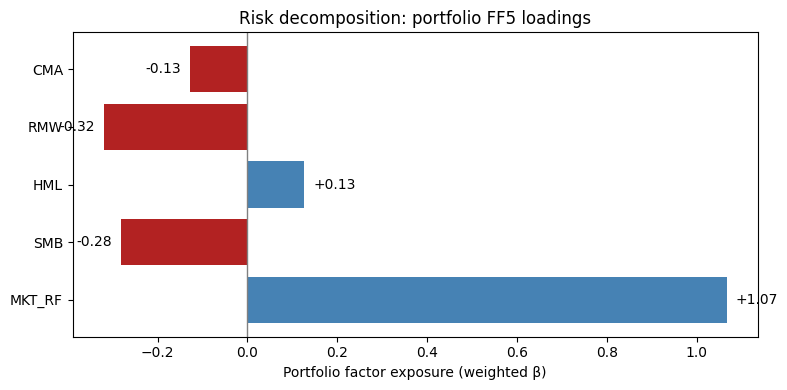

In [6]:
# Plot portfolio factor exposures
fig, ax = plt.subplots(figsize=(8, 4))
factors_for_plot = list(portfolio_betas.keys())
betas = list(portfolio_betas.values())
colors = ["steelblue" if b > 0 else "firebrick" for b in betas]
bars = ax.barh(factors_for_plot, betas, color=colors)
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Portfolio factor exposure (weighted β)")
ax.set_title("Risk decomposition: portfolio FF5 loadings")
for bar, beta in zip(bars, betas):
    x = bar.get_width()
    ax.text(x + (0.02 if x >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f"{beta:+.2f}",
            va="center",
            ha="left" if x >= 0 else "right")
plt.tight_layout()
plt.show()

**Interpreting the chart:**

Compare to a market-cap-weighted S&P 500 portfolio, which would show:
- `β_MKT_RF ≈ 1.0`, all other factor βs near zero

Deviations from that baseline are your active bets — whether you knew it or not.

**Common patterns:**
- `β_MKT > 1`: portfolio is more market-sensitive than the index — when the market goes up, you outperform; when it falls, you lose more.
- `β_SMB > 0`: small-cap-leaning. Less common on mega-cap-only portfolios.
- `β_HML < 0`: growth-leaning. Tech-heavy portfolios usually show this.
- `β_RMW > 0`: quality tilt. Defensive against earnings disappointments.
- `β_CMA > 0`: conservative-investment tilt. Capex-light, asset-efficient companies.

## 5. Realized return attribution (over the trailing year)

For the period over which we estimated the betas, decompose the *realized* portfolio return into:

$$ R^{port}_t = \sum_f \beta^f_{port} \cdot F^f_t + \alpha_{port} + \varepsilon_{port,t} $$

Then sum across days. The cumulative factor contributions plus alpha plus residuals = realized portfolio return (up to compounding effects, which we approximate by summing log-returns).

In [7]:
# Build a portfolio-daily-return series, restricted to the attribution window
all_dates = sorted(merged["date"].unique().to_list())
attribution_dates = all_dates[-ATTRIBUTION_WINDOW:]
merged_attr = merged.filter(pl.col("date").is_in(attribution_dates))

# Pivot: one row per date, one column per ticker, then weighted sum
wide = merged_attr.pivot(on="ticker", index="date", values="ret").sort("date")
weight_vec = np.array([PORTFOLIO[t] for t in tickers])
ticker_cols = wide.select(tickers).to_numpy()  # may contain nulls on some dates
# Forward-fill or drop rows with any null (defensive — early days may not have all tickers)
valid_mask = ~np.any(np.isnan(ticker_cols), axis=1)
port_daily = (ticker_cols[valid_mask] @ weight_vec)
valid_dates = [d for d, v in zip(wide["date"].to_list(), valid_mask) if v]

# Pull the matching factor returns
ff_attr = ff.filter(pl.col("date").is_in(valid_dates)).sort("date")
F = ff_attr.select(FACTORS).to_numpy()
rf_arr = ff_attr["RF"].to_numpy()

# Per-day attribution: factor_contrib_f = beta_port_f * F_f
betas_arr = np.array([portfolio_betas[f] for f in FACTORS])
factor_contrib_daily = F * betas_arr   # broadcast: (T,5) * (5,) → (T,5)
factor_total_daily = factor_contrib_daily.sum(axis=1)
port_excess_daily = port_daily - rf_arr
resid_daily = port_excess_daily - factor_total_daily

# Aggregate over the window (sum of daily log-returns ≈ cumulative log-return)
totals = {
    "Portfolio (gross)":      port_daily.sum() * 100,
    "Risk-free return":       rf_arr.sum() * 100,
    "Portfolio excess (over RF)": port_excess_daily.sum() * 100,
    **{f"  via β_{f}": (factor_contrib_daily[:, i].sum()) * 100
       for i, f in enumerate(FACTORS)},
    "  Sum of factor contributions": factor_total_daily.sum() * 100,
    "  Residual / alpha": resid_daily.sum() * 100,
}
print(f"Realized 1-year attribution ({valid_dates[0]} → {valid_dates[-1]}, {len(valid_dates)} trading days):\n")
for k, v in totals.items():
    print(f"  {k:32s} {v:+7.2f}%")

Realized 1-year attribution (2025-05-06 → 2026-03-31, 227 trading days):

  Portfolio (gross)                 +29.23%
  Risk-free return                   +4.13%
  Portfolio excess (over RF)        +25.10%
    via β_MKT_RF                    +13.86%
    via β_SMB                        -1.72%
    via β_HML                        +1.39%
    via β_RMW                        +2.83%
    via β_CMA                        -0.65%
    Sum of factor contributions     +15.71%
    Residual / alpha                 +9.39%


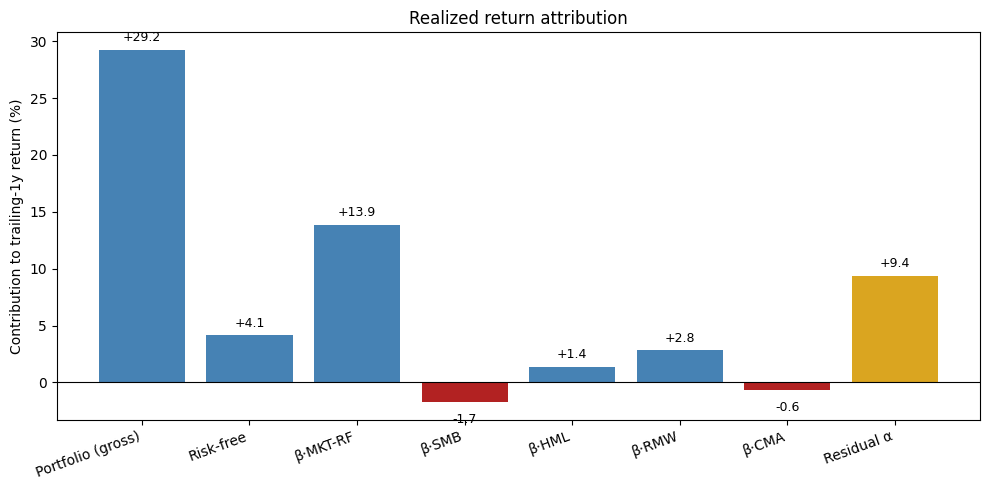

In [8]:
# Attribution bar chart: stacked / waterfall view
fig, ax = plt.subplots(figsize=(10, 5))
items = [("Portfolio (gross)", port_daily.sum() * 100, "steelblue"),
         ("Risk-free", rf_arr.sum() * 100, "lightgray"),
         ("β·MKT-RF", factor_contrib_daily[:, 0].sum() * 100, "steelblue"),
         ("β·SMB",    factor_contrib_daily[:, 1].sum() * 100, "steelblue"),
         ("β·HML",    factor_contrib_daily[:, 2].sum() * 100, "steelblue"),
         ("β·RMW",    factor_contrib_daily[:, 3].sum() * 100, "steelblue"),
         ("β·CMA",    factor_contrib_daily[:, 4].sum() * 100, "steelblue"),
         ("Residual α", resid_daily.sum() * 100, "goldenrod")]
labels = [x[0] for x in items]
values = [x[1] for x in items]
colors = ["steelblue" if v >= 0 else "firebrick" for _, v, _ in items]
# Override the residual α colour so it stands out
colors[-1] = "goldenrod" if values[-1] >= 0 else "darkred"
bars = ax.bar(labels, values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Contribution to trailing-1y return (%)")
ax.set_title("Realized return attribution")
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            value + (0.5 if value >= 0 else -1.0),
            f"{value:+.1f}",
            ha="center",
            va="bottom" if value >= 0 else "top",
            fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Reading the attribution chart:**

- **Portfolio (gross)** is what you actually earned over the trailing year (log-return units).
- The five `β·FACTOR` bars decompose that into what was *explained* by the portfolio's factor exposures times the realized factor returns.
- **Residual α** is what's left over — the part of your return that the factor model can't explain. This is the *true* stock-picking contribution.

**Common readings:**
- Positive residual α → stock-picking added value (or one big lucky position dominated)
- Negative residual α → individual ticker selection detracted, even if the factor exposures earned
- Most of the return in the β·MKT-RF bar → you were just long the market; the rest is noise around that bet

**One caveat:** sub-1-year attribution is noisy. A single ticker's idiosyncratic move (e.g., NVDA in 2023-24) can dwarf the smooth factor signal.

## 6. Idiosyncratic risk concentration

Even within a 10-ticker equal-weight portfolio, individual tickers contribute very different amounts of *unexplained* (idiosyncratic) risk. High-idio-vol names dominate the residual variance.

In [9]:
# Weighted contribution to portfolio idio variance
# Assuming idio shocks are uncorrelated (Strong assumption — only true if FF5 captures all common variation,
# but a reasonable first-order approximation.):
# Var(port_idio) ≈ Σ w_i² · σ_idio_i²
lw_sorted = lw.with_columns(
    ((pl.col("weight") ** 2) * (pl.col("idio_vol_ann") ** 2)).alias("idio_var_contrib")
).sort("idio_var_contrib", descending=True)
total_idio_var = lw_sorted["idio_var_contrib"].sum()
lw_sorted = lw_sorted.with_columns(
    (pl.col("idio_var_contrib") / total_idio_var * 100).alias("share_of_idio_pct")
)
ann_idio_vol_port = float(np.sqrt(total_idio_var)) * 100

print(f"Estimated annualized idio vol of the portfolio: {ann_idio_vol_port:.2f}%")
print("(Assumes per-stock residual shocks are uncorrelated — a first-order approximation.)\n")
print("Concentration of unexplained risk by ticker:")
lw_sorted.select("ticker", "weight", "idio_vol_ann", "share_of_idio_pct")

Estimated annualized idio vol of the portfolio: 9.07%
(Assumes per-stock residual shocks are uncorrelated — a first-order approximation.)

Concentration of unexplained risk by ticker:


ticker,weight,idio_vol_ann,share_of_idio_pct
str,f64,f64,f64
"""MU""",0.1,0.493172,29.585798
"""AMD""",0.1,0.442208,23.786975
"""ANET""",0.1,0.407658,20.215232
"""WMT""",0.1,0.211081,5.419816
"""BLK""",0.1,0.181482,4.006379
"""MSFT""",0.1,0.180928,3.98199
"""COST""",0.1,0.179569,3.922397
"""AAPL""",0.1,0.1787,3.884493
"""JPM""",0.1,0.157543,3.01915


**Reading the idio table:**
- The `share_of_idio_pct` column shows the fraction of a portfolio's *unexplained risk* contributed by each ticker.
- At equal weights, tickers with higher individual idio vol dominate. A 10-ticker portfolio is rarely as diversified as it appears — typically 2-3 tickers drive >50% of the residual risk.
- If those top contributors are also high-conviction tickers, that is acceptable. If they are "just along for the ride," they constitute risk that may not have been recognized you were taking.

## Summary template

After running this notebook, the one-paragraph summary writes itself:

> Over the trailing 1 year, the portfolio earned `{X}%` gross return. The Fama-French 5-factor model attributes `{Y}%` of that to factor exposures — primarily a market beta of `{β_mkt}` and `{value/growth/quality}` tilts — with `{Z}%` of residual stock-picking alpha. Approximately `{N}%` of the portfolio's idiosyncratic risk comes from its top two contributors, `{tickerA}` and `{tickerB}`, suggesting the diversification benefit of equal-weighting is partially offset by single-name concentration in unexplained variance.

**This is the kind of analysis institutional risk teams produce daily.** It doesn't require alpha. The infrastructure built for the cross-sectional return predictor — factor data adapter, rolling betas, panel joins — is the same machinery that answers "what is this portfolio really betting on?"

---

**Not financial advice.** This notebook is a research artifact, not portfolio guidance. Any rebalancing decision should be made with a fiduciary and account for tax consequences and transaction costs that are not modeled here.